# 지수 평활(PROC ESM)로 응급실 방문량 예측하기

## 요약

한 중형 병원 시스템은 겨울철 호흡기 급증에 앞서 간호 인력과 병상 용량을 계획하기 위해 월별 응급실(ED) 방문량의 1년 앞 예측이 필요합니다. 이 노트북은 4년치 합성 월별 ED 방문량(48개월, 2021년 1월 - 2024년 12월)을 구축하고 **PROC ESM**으로 Winters 승법 계절 모델을 적합하여 95% 예측 구간을 갖춘 12개월 예측을 산출합니다.

적합된 모델은 시계열을 잘 포착합니다: 표본 내 **RMSE는 약 320 방문**, **MAPE는 4.16%**로, 전형적인 월별 오차가 방문량의 5% 미만입니다. 예측은 익숙한 계절 형태를 2025년으로 투영합니다 - 12월-2월 정점은 **월 7,300-7,800 방문** 부근, 늦여름 저점은 **5,800-5,900** 부근 - 예측 구간은 지평이 멀어질수록 넓어집니다. 그 수치와 그 뒤의 평활 가중치는 아래 프로시저 출력 데이터셋에서 직접 읽어옵니다.

## 데이터 소스

| 데이터셋 | 행 수 | 단위 | 주요 변수 | 설명 |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | 달력 월당 한 행, 2021년 1월 - 2024년 12월 | `month`(월별 SAS 날짜), `ed_visits`(월별 정수 ED 방문 수) | 중형 병원 시스템의 합성 월별 응급실 방문량. 상향 성장 추세(연 약 3%), 겨울 호흡기철(12월-2월)에 정점을 찍고 늦여름에 낮아지는 승법 계절 주기, 그리고 계절 진폭이 상승하는 수준에 비례하도록 하는 로그정규 잡음을 더해 생성했다. |

# PROC ESM으로 응급실 방문량 예측하기

용량 계획 담당자는 간호사를 배치하고 유연 병상을 확보하며 겨울 급증에 앞서 호흡기 물자를 준비하려면 매달 몇 건의 ED 방문을 예상해야 하는지 알아야 합니다. ED 방문량은 교과서적인 계절 시계열입니다: 해마다 천천히 성장하고, 12월-2월 호흡기철에 정점을 찍으며, 늦여름에 잦아들고, 계절 변동의 크기는 기저 방문량이 커질수록 함께 커집니다. 그 승법 계절 구조가 바로 **PROC ESM**의 Winters 승법 방법이 포착하도록 설계된 것입니다.

이 노트북에서 우리는 다음을 수행합니다:

1. 추세, 승법 계절성, 잡음을 갖춘 현실적인 4년치 월별 ED 방문량을 생성합니다.
2. 시계열을 시각화해 승법 계절 구조를 확인합니다.
3. PROC ESM으로 Winters 승법 모델을 적합하고 출력 데이터셋에서 평활 가중치와 적합 통계량을 읽습니다.
4. 95% 예측 구간을 갖춘 12개월 앞 예측을 산출하고 운영적 함의를 해석합니다.

## 1단계 - 합성 월별 ED 방문량 생성

우리는 2021년 1월부터 2024년 12월까지 월별 관측치 48개를 구축합니다. 각 달의 기대 방문량은 연 약 3% 성장하는 기저 수준에 계절 지수(한겨울에 최고, 늦여름에 최저)를 곱한 뒤, 무작위 변동이 수준에 비례하도록 로그정규 잡음으로 교란한 값입니다. `intnx`는 행마다 월-정렬 날짜를 한 주기씩 전진시키고, `streaminit`은 추출을 재현 가능하게 만듭니다.

In [1]:
데이터 ed_census;
    호출 streaminit(20240531);
    /* 월별 계절 지수: 12~2월(독감/RSV) 정점, 8~9월 저점 */
    배열 seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    형식 month yymmn6.;
    반복 i = 1 까지 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* 기준선 월 약 6000건, 연 약 3% 증가 */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* 곱셈형 계절성 + 수준에 비례한 로그정규 잡음 */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        출력;
    종료;
    유지 month ed_visits;
실행;

처리 인쇄 데이터=ed_census(obs=14) noobs 라벨;
    라벨 month = "월" ed_visits = "응급실 내원 건수";
    제목 "합성 응급실 내원량의 처음 14개월";
실행;

                                                  합성 응급실 내원량의 처음 14개월                                                   

     월                응급실 내원 건수
202101                     7103
202102                     6835
202103                     6668
202104                     5611
202105                     5816
202106                     5383
202107                     5586
202108                     5283
202109                     5161
202110                     6109
202111                     6451
202112                     6730
202201                     6847
202202                     7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


첫 달들이 설계를 확인해 줍니다: 방문량은 2021년 1월 정점에서 7,100 부근으로 시작해 봄과 여름을 지나 8-9월 저점으로 떨어졌다가 다음 겨울로 다시 올라갑니다. 2022년 1월이면 정점이 약 6,800-7,200으로 올라가, 계절 주기 위에 얹힌 연 약 3% 성장을 반영합니다.

## 2단계 - 시계열 시각화

모델링에 앞서, 원 시계열을 그려 우리가 기대하는 구조를 확인합니다: 완만한 상향 추세와 겨울마다 반복되며 시간이 갈수록 진폭이 넓어지는 연간 정점. 넓어지는 계절 변동은 *승법* 계절 과정의 특징이며, 어떤 ESM 모델을 선택해야 하는지 알려 줍니다.

                                                  합성 응급실 내원량의 처음 14개월                                                   




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


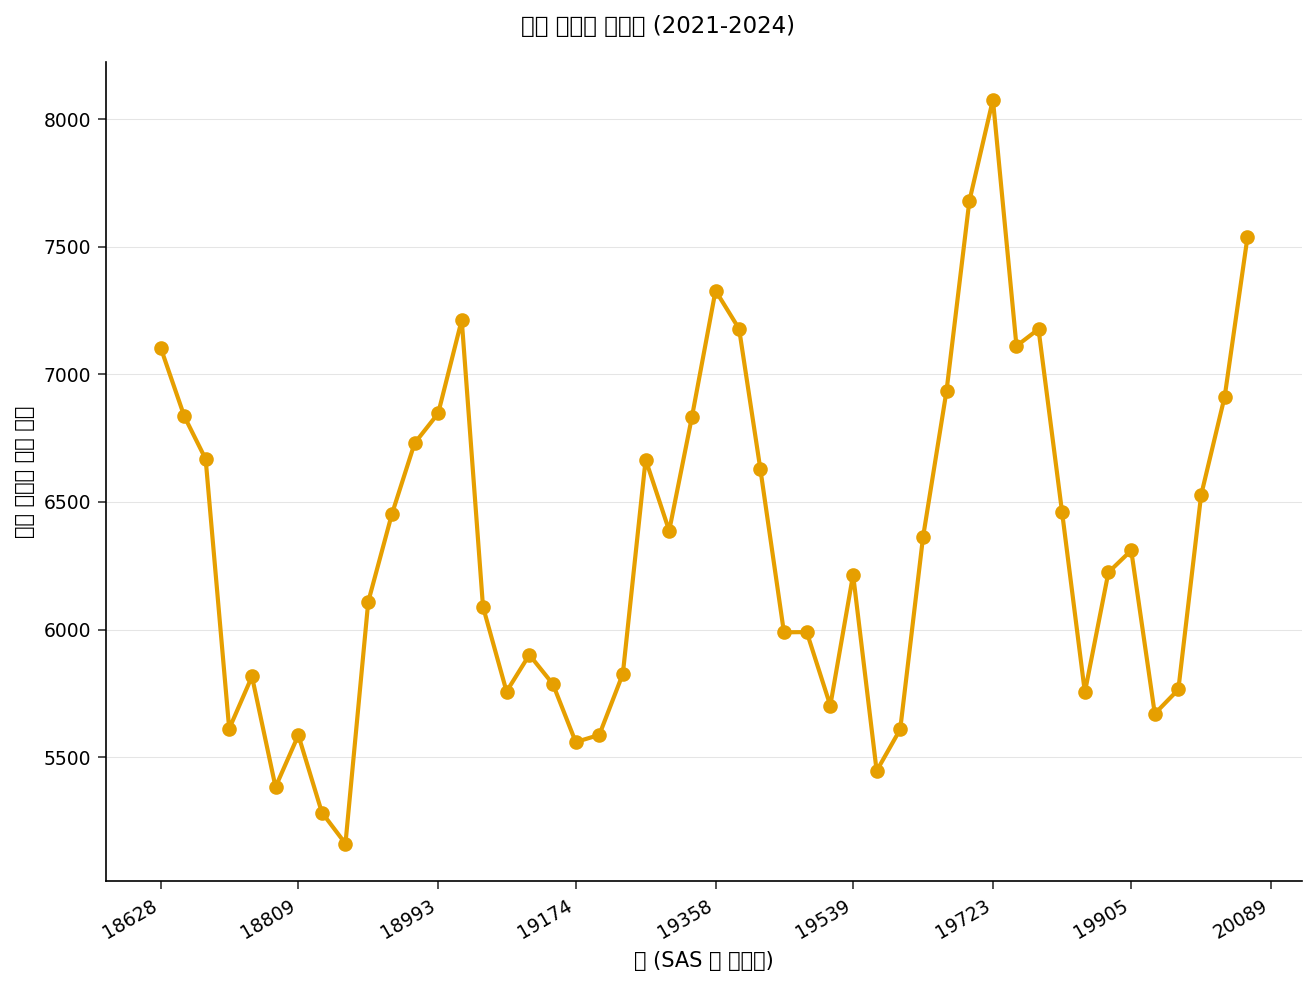

In [2]:
처리 SGPLOT 데이터=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS 라벨="월 (SAS 월 인덱스)";
    YAXIS 라벨="월별 응급실 내원 건수" grid;
    제목 "월별 응급실 내원량 (2021-2024)";
실행;

그림은 네 개의 깔끔한 연간 주기를 보여 줍니다. 각 겨울 정점은 직전보다 조금씩 높아져 2021년 약 7,100에서 2024년 정점 약 8,100으로 올라가는 반면, 여름 저점은 더 완만하게 오릅니다 - 계절 변동이 수준과 함께 커집니다. 그 넓어지는 진폭이 승법 계절성의 증표이며 다음 단계에서 `MODEL=WINTERS`(Winters 승법)를 정당화합니다.

## 3단계 - Winters 승법 모델 적합

우리는 전체 48개월 이력에 Winters 승법 계절 평활을 적합합니다. `ID` 문은 `month`를 `MONTH` 간격의 시간 인덱스로 선언하고, `FORECAST` 문은 1년 앞을 투영하기 위해 `LEAD=12`와 함께 `MODEL=WINTERS`를 요청합니다. 우리는 세 개의 출력 데이터셋을 포착합니다:

- `OUT=` - 예측이 덧붙은 이력 시계열(`ed_visits` 열 하나), 시간 ID가 예측 지평까지 확장됨 - 그래프에 이상적.
- `OUTFOR=` - 주기별 예측 구성요소: 점 예측(`PREDICT`)과 하한/상한 예측 한계.
- `OUTSUM=` - 모델의 적합 통계량(RMSE, MAE, MAPE, AIC)과 평활 가중치, 단일 요약 행으로.

`ALPHA=0.05`는 95% 예측 한계를 산출하며, 용량 계획 위험 여유에 적절합니다. `PRINT=(STATISTICS)`는 적합 통계량과 평활 가중치를 리스팅에 출력합니다.

In [3]:
처리 esm 데이터=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        인쇄=(statistics);
    id month interval=month;
    forecast ed_visits / 모형=winters ALPHA=0.05;
실행;

처리 인쇄 데이터=esm_summary noobs 라벨;
    라벨 rmse="RMSE" mae="MAE" mape="MAPE"
          ALPHA="수준(alpha)" beta="추세(beta)" gamma="계절(gamma)";
    변수 rmse mae mape ALPHA beta gamma;
    제목 "윈터스 적합 통계량과 평활 가중치";
실행;

                                                  합성 응급실 내원량의 처음 14개월                                                   


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                                   윈터스 적합 통계량과 평활 가중치                                                   

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


`OUTSUM=` 행과 출력된 통계량이 일치합니다: Winters 승법 적합은 표본 내 **RMSE 320.4 방문**, **MAE 264.4**, **MAPE 4.16%**를 달성합니다 - 전형적 월별 오차가 방문량의 5%를 넉넉히 밑돌아 인력 계획에 충분히 정확합니다. 평활 가중치는 **alpha = 0.30**(수준), **beta = 0.10**(추세), **gamma = 0.10**(계절)입니다. 적당한 수준 가중치는 기저선이 환자 인구 성장과 함께 위로 표류하도록 하고, 작은 추세·계절 가중치는 성장률과 겨울 급증 형태가 해마다 안정적이어서 달마다 과잉 반응해서는 안 됨을 반영합니다.

> 참고: 이것들은 추정 표본 위에서 계산된 *표본 내* 적합 통계량이지, 표본 외 홀드아웃이 아닙니다. 모델이 자신이 적합된 이력을 얼마나 가깝게 따라가는지를 정량화합니다.

## 4단계 - 12개월 예측 조립 및 표로 정리

`OUTFOR=` 데이터셋은 모든 주기의 점 예측과 예측 한계를 담고, `OUT=` 데이터셋은 예측 지평까지 깔끔하게 확장된 시간 ID를 담습니다. 우리는 둘을 관측 순서로 정렬해 예측 한계에 예측 날짜를 붙인 뒤, 12개 예측 월만 남깁니다. 이것이 인력 계획 위원회가 근거로 삼을 수치입니다.

In [4]:
/* OUT=는 예측 구간의 날짜를, OUTFOR=는 예측한계를 담는다.
   관측 순서로 정렬해 한계에 날짜를 붙인 뒤, 예측 12개월만 남긴다. */
데이터 out_idx;
    설정 ed_with_forecast;
    row = _n_;
    개명 month = fdate ed_visits = series_value;
실행;

데이터 for_idx;
    설정 esm_forecast;
    row = _n_;
    개명 ed_visits = observed;
    유지 row observed predict LOWER UPPER;
실행;

데이터 forecast_path;
    결합 out_idx for_idx;
    기준 row;
    형식 fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
실행;

데이터 forecast_horizon;
    설정 forecast_path;
    조건 observed = .;   /* 관측값이 없는 예측 월만 */
    유지 fdate predict LOWER UPPER;
실행;

처리 인쇄 데이터=forecast_horizon noobs 라벨;
    라벨 fdate   = "월"
          predict = "예측 내원 건수"
          LOWER   = "95% 하한"
          UPPER   = "95% 상한";
    제목 "95% 예측한계를 포함한 12개월 응급실 내원 예측";
실행;

                                              95% 예측한계를 포함한 12개월 응급실 내원 예측                                              

     월              예측 내원 건수      95% 하한      95% 상한
202501                 7,822       7,194       8,450
202502                 7,539       6,651       8,427
202503                 7,292       6,204       8,380
202504                 6,263       5,007       7,519
202505                 6,397       4,992       7,801
202506                 6,039       4,501       7,578
202507                 6,236       4,574       7,897
202508                 5,867       4,091       7,644
202509                 5,802       3,918       7,686
202510                 6,804       4,818       8,790
202511                 7,173       5,090       9,256
202512                 7,567       5,391       9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


예측은 계절 특징을 2025년으로 이어 갑니다. 모델은 2025년 1월 정점을 약 **7,822 방문**(95% 구간 7,194-8,450)으로 투영하고, 봄에 걸쳐 완화되어 9월 늦여름 저점 **5,802** 부근(구간 3,918-7,686)에서 바닥을 친 뒤, 12월 정점 약 **7,567**(구간 5,391-9,742)로 다시 올라갑니다. 예측 구간은 지평과 함께 꾸준히 넓어집니다 - 다음 달 구간은 약 +/-630 방문에 걸쳐 있는 반면 다음 12월 구간은 +/-2,000을 넘습니다 - 단기 계획이 연말 계획보다 훨씬 더 확실하다는 직접적인 상기입니다.

## 5단계 - 이력과 예측 함께 그리기

마지막으로, 관측된 이력 위에 예측을 겹쳐 계획 담당자가 투영된 겨울 정점과 지평이 멀어질수록 넓어지는 불확실성 밴드를 볼 수 있게 합니다. 우리는 정렬된 `forecast_path` 시계열을 **관측된** 이력(실선)과 **12개월 예측**(점선)으로 나눠 인계 지점을 분명히 하고, 그 아래에 95% 예측 밴드를 그립니다. x축은 월별 SAS 날짜 인덱스로, 2021년 1월부터 2025년 12월까지 왼쪽에서 오른쪽으로 진행합니다.

                                              95% 예측한계를 포함한 12개월 응급실 내원 예측                                              




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


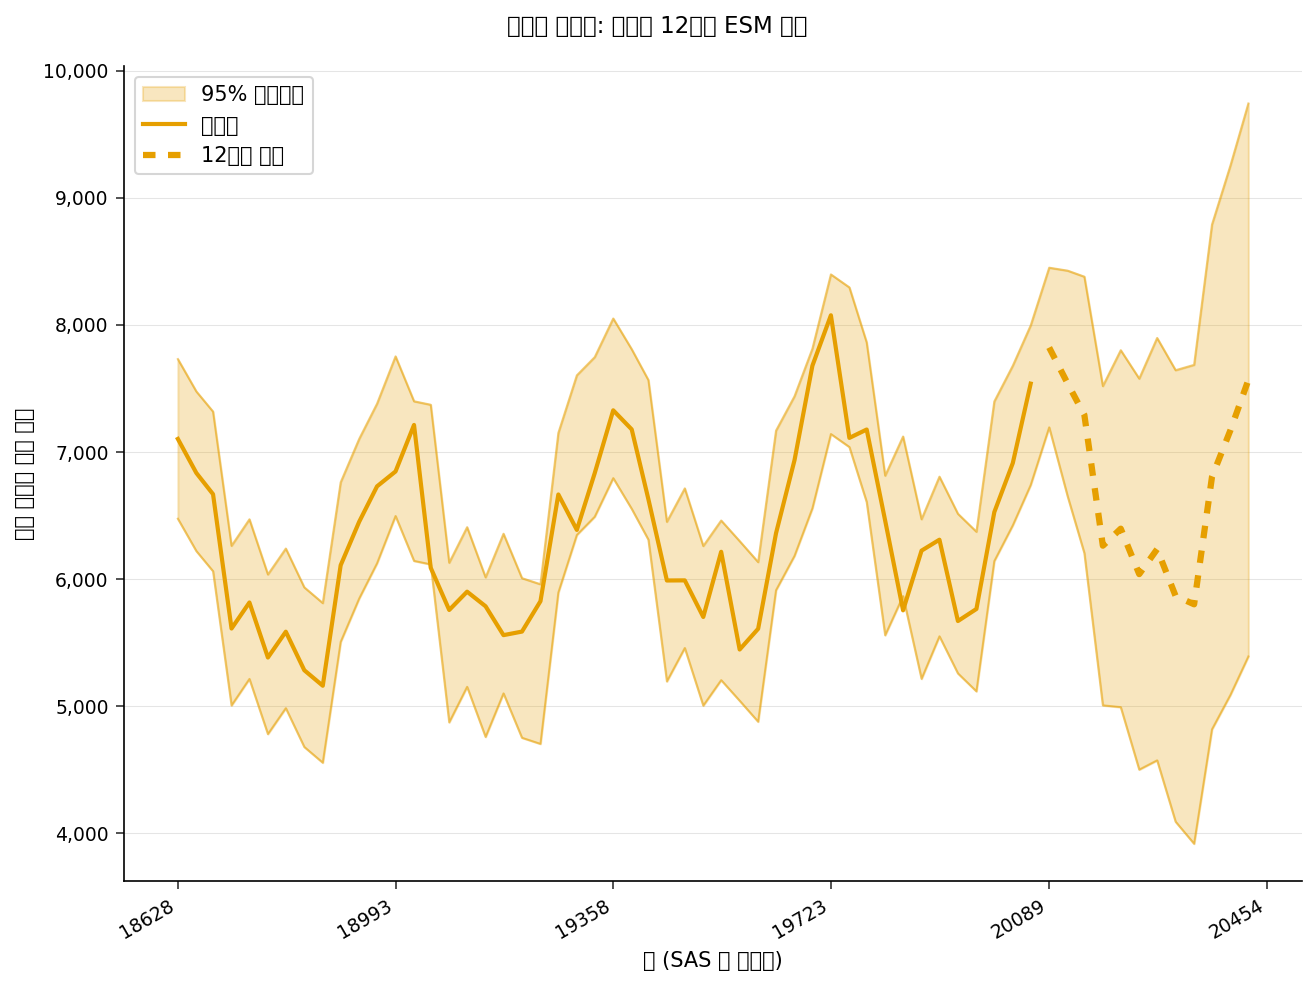

In [5]:
/* 투영된 시계열을 관측 이력과 12개월 예측으로 나누어 서로 다른
   스타일로 그리고, 정렬된 forecast_path 데이터셋의 95% 예측 밴드를
   겹쳐 표시한다. */
데이터 forecast_plot;
    설정 forecast_path;
    만약 observed = . 이면 fc_only = predict;   /* 미래 월만 */
    아니면 fc_only = .;
실행;

처리 SGPLOT 데이터=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel="95% 예측구간" TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel="관측값";
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel="12개월 예측";
    XAXIS 라벨="월 (SAS 월 인덱스)";
    YAXIS 라벨="월별 응급실 내원 건수" grid;
    제목 "응급실 내원량: 실적과 12개월 ESM 예측";
실행;

## 결과 해석

Winters 승법 모델은 ED 방문량을 천천히 상승하는 **수준(level)**, 거의 평평한 **추세(trend)**, 안정적인 **계절(seasonal)** 패턴으로 분해합니다. `OUTSUM=`에서 읽은 평활 가중치가 이야기를 들려줍니다: 적당한 수준 가중치(alpha = 0.30)는 기저선이 환자 인구 성장과 함께 위로 표류하도록 하고, 작은 추세·계절 가중치(beta = gamma = 0.10)는 성장률과 겨울 급증 형태가 해마다 매우 안정적이어서 달마다 과잉 반응해서는 안 됨을 반영합니다.

**적합 통계량**은 모델이 이력을 잘 따라감을 확인합니다: 약 320 방문의 RMSE와 4.16%의 MAPE는 전형적 월별 오차가 방문량의 5% 미만임을 뜻합니다. 운영적으로, **예측 표와 밴드 그림**은 ED가 인력을 맞춰야 할 12월-2월 정점 - 겨울철 대략 7,300-7,800 방문 - 을 정량화하고, 95% 예측 한계는 신중한 용량 범위를 정의합니다: 핵심 인력은 점 예측에 맞추고, 유연 인력과 급증 병상은 상한 쪽으로 사전 준비합니다. 구간은 지평과 함께 넓어지므로 다음 달 계획은 다음 12월보다 훨씬 확실하며, 새로운 실적이 도착하는 대로 갱신해야 합니다.

**확장:** `MODEL=ADDWINTERS`(가법 계절성)를 승법 적합과 비교해 승법 선택을 확인하거나, `TRANSFORM=LOG`를 적용해 양수성을 강제하고 분산을 안정화하거나, `BY` 문을 추가해 하나의 PROC ESM 호출로 여러 병원 사이트를 예측할 수 있습니다.